# Tangram validation benchmark for Br8667

This notebook adapts the Tangram + Squidpy tutorial to the frozen Br8667 benchmark.

**Experiment**
- Reference: Huuki snRNA-seq.
- Spatial input: Xenium Br8667 with only the 210 frozen training genes.
- Development truth: 45 frozen validation genes.
- Blind test: not loaded or evaluated here.
- Primary metric: median gene-wise Spearman across spatial cells.

Tangram maps reference cells or reference clusters to spatial locations using the shared training genes, then projects reference expression into spatial cells for held-out gene evaluation.


## Install Tangram

```bash
conda activate /scratch/mjabin/conda_envs/Imputation
pip install tangram-sc
```

This notebook defaults to **cluster mode**, which is much lighter for your 66k Xenium cells. Set `TANGRAM_MODE = "cells"` later for the heavier cell-level version.


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/users/mjabin/projects/GeneBridge")
BASE_DIR = PROJECT_ROOT / "data/processed/imputation_beta/Br8667"

SEQ_PATH = BASE_DIR / "seq_data_huuki_snrna_Br8667_vista.h5ad"
SPATIAL_TRAIN_PATH = BASE_DIR / "benchmark/inputs/spatial_train_210genes.h5ad"
VALIDATION_TRUTH_PATH = BASE_DIR / "benchmark/truth/validation_truth_45genes.h5ad"
VALIDATION_SPLIT_PATH = BASE_DIR / "benchmark/splits/validation_genes_45.csv"
DEVELOPMENT_CELL_IDS_PATH = BASE_DIR / "benchmark/splits/development_cell_ids.csv"

PREDICTION_DIR = BASE_DIR / "benchmark/predictions"
OUTPUT_ROOT = PROJECT_ROOT / "outputs/imputation_beta/Br8667"
REPORT_DIR = OUTPUT_ROOT / "validation/tangram"
FIGURE_DIR = REPORT_DIR / "figures"

for d in [PREDICTION_DIR, REPORT_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#RUN_MODE = "smoke"        # "smoke" or "full"
RUN_MODE = "full"        # "smoke" or "full"
TANGRAM_MODE = "clusters" # "clusters" or "cells"
RANDOM_SEED = 8667
NORMALIZATION_TARGET_SUM = 1e4

SMOKE_EPOCHS = 50
FULL_EPOCHS = 500
NUM_EPOCHS = SMOKE_EPOCHS if RUN_MODE == "smoke" else FULL_EPOCHS

SMOKE_REFERENCE_CELLS = 2000
SMOKE_SPATIAL_CELLS = 5000

DEVICE = "cuda:0"         # full cell mode: use cuda:0 when available; otherwise cpu
DENSITY_PRIOR = "uniform" # Xenium cells are single-cell resolution

SC_CLUSTER_LABEL_CANDIDATES = [
    "cellType_broad_k",
    "cell_type",
    "cell_type_annotation",
    "scClassify",
    "labels",
]
MIN_REFERENCE_CELLS_PER_CLUSTER = 10
N_SPATIAL_GENES_TO_PLOT = 4

if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("RUN_MODE must be smoke or full.")
if TANGRAM_MODE not in {"clusters", "cells"}:
    raise ValueError("TANGRAM_MODE must be clusters or cells.")

RUN_SUFFIX = f"_{TANGRAM_MODE}_smoke" if RUN_MODE == "smoke" else f"_{TANGRAM_MODE}"
PREDICTION_PATH = PREDICTION_DIR / f"tangram_validation_predictions_45genes{RUN_SUFFIX}.h5ad"
MAP_PATH = REPORT_DIR / f"16_tangram_map{RUN_SUFFIX}.h5ad"

print("Run mode:", RUN_MODE)
print("Tangram mode:", TANGRAM_MODE)
print("Epochs:", NUM_EPOCHS)
print("Prediction path:", PREDICTION_PATH)


Run mode: smoke
Tangram mode: cells
Epochs: 50
Prediction path: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/tangram_validation_predictions_45genes_cells_smoke.h5ad


## 1. Imports

In [21]:
import inspect
import time
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
from scipy import sparse
from scipy.stats import pearsonr, spearmanr
import torch

from IPython.display import display

np.random.seed(RANDOM_SEED)

try:
    import tangram as tg
except ImportError as e:
    raise ImportError("Tangram is missing. Install with: pip install tangram-sc") from e

print("Scanpy:", sc.__version__)
print("AnnData:", ad.__version__ if hasattr(ad, "__version__") else "unknown")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nmap_cells_to_space:", inspect.signature(tg.map_cells_to_space))
print("project_genes:", inspect.signature(tg.project_genes))


Scanpy: 1.9.3
AnnData: 0.9.2
PyTorch: 2.1.2+cu118
CUDA available: False

map_cells_to_space: (adata_sc, adata_sp, cv_train_genes=None, cluster_label=None, mode='cells', device='cpu', learning_rate=0.1, num_epochs=1000, scale=True, lambda_d=0, lambda_g1=1, lambda_g2=0, lambda_r=0, lambda_count=1, lambda_f_reg=1, target_count=None, random_state=None, verbose=True, density_prior='rna_count_based')
project_genes: (adata_map, adata_sc, cluster_label=None, scale=True)


## 2. Helper functions

In [22]:
def row_sums(matrix):
    if sparse.issparse(matrix):
        return np.asarray(matrix.sum(axis=1)).ravel()
    return np.asarray(matrix).sum(axis=1)


def dense_float32(matrix):
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def normalized_log_matrix_from_adata(adata, genes, library_sizes, target_sum=1e4):
    genes = [str(g) for g in genes]
    pos = adata.var_names.astype(str).get_indexer(genes)
    if np.any(pos < 0):
        missing = [genes[i] for i, p in enumerate(pos) if p < 0]
        raise ValueError(f"Missing genes: {missing[:20]}")

    counts = dense_float32(adata[:, genes].X)
    library_sizes = np.asarray(library_sizes, dtype=np.float32)
    if np.any(library_sizes <= 0):
        raise ValueError("Library sizes contain zero or negative values.")

    return np.log1p(counts / library_sizes[:, None] * float(target_sum)).astype(np.float32)


def make_adata(X, obs, genes):
    out = ad.AnnData(
        X=X.astype(np.float32, copy=False),
        obs=obs.copy(),
        var=pd.DataFrame(index=pd.Index(genes).astype(str)),
    )
    out.obs_names = obs.index.astype(str)
    out.var_names = pd.Index(genes).astype(str)
    return out


def first_existing_column(df, candidates):
    return next((c for c in candidates if c in df.columns), None)


def safe_spearman(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan
    r = spearmanr(x, y)
    return float(r.statistic if hasattr(r, "statistic") else r[0])


def safe_pearson(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan
    r = pearsonr(x, y)
    return float(r.statistic if hasattr(r, "statistic") else r[0])


def zscore(v):
    v = np.asarray(v, dtype=np.float64)
    sd = np.std(v)
    if not np.isfinite(sd) or sd <= 1e-12:
        return np.full_like(v, np.nan, dtype=np.float64)
    return (v - np.mean(v)) / sd


def calculate_gene_metrics(observed, predicted, genes):
    records = []
    for j, gene in enumerate(genes):
        obs = observed[:, j]
        pred = predicted[:, j]
        obs_z = zscore(obs)
        pred_z = zscore(pred)
        m = np.isfinite(obs_z) & np.isfinite(pred_z)
        records.append({
            "gene": gene,
            "spearman_across_cells": safe_spearman(obs, pred),
            "pearson_across_cells": safe_pearson(obs, pred),
            "mae_standardized": float(np.mean(np.abs(pred_z[m] - obs_z[m]))) if m.any() else np.nan,
            "rmse_standardized": float(np.sqrt(np.mean((pred_z[m] - obs_z[m]) ** 2))) if m.any() else np.nan,
            "observed_mean": float(np.mean(obs)),
            "predicted_mean": float(np.mean(pred)),
            "observed_variance": float(np.var(obs)),
            "predicted_variance": float(np.var(pred)),
            "observed_nonzero_fraction": float(np.mean(obs > 0)),
            "predicted_positive_fraction": float(np.mean(pred > 0)),
        })
    return pd.DataFrame(records)


def calculate_pseudobulk_metrics(observed, predicted, genes, obs, group_column):
    if group_column is None or group_column not in obs.columns:
        return pd.DataFrame()
    groups = obs[group_column].astype(str).to_numpy()
    records = []
    for j, gene in enumerate(genes):
        obs_means = []
        pred_means = []
        for group in sorted(pd.unique(groups)):
            mask = groups == group
            obs_means.append(float(observed[mask, j].mean()))
            pred_means.append(float(predicted[mask, j].mean()))
        records.append({
            "gene": gene,
            "group_column": group_column,
            "n_groups": len(obs_means),
            "pseudobulk_spearman": safe_spearman(obs_means, pred_means),
            "pseudobulk_pearson": safe_pearson(obs_means, pred_means),
        })
    return pd.DataFrame(records)


def parse_training_history(history):
    if history is None:
        return pd.DataFrame()
    if isinstance(history, pd.DataFrame):
        return history.copy()
    if isinstance(history, dict):
        return pd.DataFrame({k: pd.Series(v) for k, v in history.items()})
    if isinstance(history, (list, tuple)):
        return pd.DataFrame({"record": np.arange(1, len(history) + 1), "value": history})
    return pd.DataFrame({"training_history_repr": [repr(history)]})


## 3. Load and validate frozen inputs

In [23]:
for p in [SEQ_PATH, SPATIAL_TRAIN_PATH, VALIDATION_TRUTH_PATH, VALIDATION_SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

seq_data = ad.read_h5ad(SEQ_PATH)
spatial_train = ad.read_h5ad(SPATIAL_TRAIN_PATH)
validation_truth = ad.read_h5ad(VALIDATION_TRUTH_PATH)
validation_split = pd.read_csv(VALIDATION_SPLIT_PATH)

train_genes = spatial_train.var_names.astype(str).tolist()
validation_genes = validation_truth.var_names.astype(str).tolist()
seq_gene_set = set(seq_data.var_names.astype(str))

checks = {
    "train genes = 210": len(train_genes) == 210,
    "validation genes = 45": len(validation_genes) == 45,
    "train/validation disjoint": set(train_genes).isdisjoint(validation_genes),
    "all train genes in reference": set(train_genes).issubset(seq_gene_set),
    "all validation genes in reference": set(validation_genes).issubset(seq_gene_set),
    "spatial cells match truth": spatial_train.obs_names.equals(validation_truth.obs_names),
    "spatial coordinates present": "spatial" in spatial_train.obsm,
}
for k, v in checks.items():
    print(k, v)
if not all(checks.values()):
    raise ValueError([k for k, v in checks.items() if not v])

if DEVELOPMENT_CELL_IDS_PATH.exists():
    cell_ids = pd.read_csv(DEVELOPMENT_CELL_IDS_PATH)["cell_id"].astype(str).tolist()
    spatial_train = spatial_train[cell_ids].copy()
    validation_truth = validation_truth[cell_ids].copy()
    print("Reused development cell list:", len(cell_ids))
else:
    keep = row_sums(spatial_train.X) > 0
    cell_ids = spatial_train.obs_names[keep].astype(str).tolist()
    spatial_train = spatial_train[cell_ids].copy()
    validation_truth = validation_truth[cell_ids].copy()
    pd.DataFrame({"cell_id": cell_ids}).to_csv(DEVELOPMENT_CELL_IDS_PATH, index=False)
    print("Created development cell list:", len(cell_ids))

print("snRNA:", seq_data.shape)
print("spatial train:", spatial_train.shape)
print("validation truth:", validation_truth.shape)


train genes = 210 True
validation genes = 45 True
train/validation disjoint True
all train genes in reference True
all validation genes in reference True
spatial cells match truth True
spatial coordinates present True
Reused development cell list: 66154
snRNA: (9897, 28907)
spatial train: (66154, 210)
validation truth: (66154, 45)


## 4. Cluster label and smoke subsets

In [24]:
cluster_label = first_existing_column(seq_data.obs, SC_CLUSTER_LABEL_CANDIDATES)
print("Selected reference cluster label:", cluster_label)

if TANGRAM_MODE == "clusters" and cluster_label is None:
    raise ValueError("Cluster mode requires a cell-type/cluster label in seq_data.obs.")

if cluster_label is not None:
    counts = seq_data.obs[cluster_label].astype(str).value_counts()
    display(counts)
    keep_ref = seq_data.obs[cluster_label].astype(str).map(counts) >= MIN_REFERENCE_CELLS_PER_CLUSTER
    if int((~keep_ref).sum()) > 0:
        seq_data = seq_data[keep_ref].copy()
        print("Removed small-cluster reference cells:", int((~keep_ref).sum()))

rng = np.random.default_rng(RANDOM_SEED)

if RUN_MODE == "smoke":
    ref_n = min(SMOKE_REFERENCE_CELLS, seq_data.n_obs)
    sp_n = min(SMOKE_SPATIAL_CELLS, spatial_train.n_obs)
    ref_idx = np.sort(rng.choice(seq_data.n_obs, ref_n, replace=False))
    sp_idx = np.sort(rng.choice(spatial_train.n_obs, sp_n, replace=False))
    seq_data = seq_data[ref_idx].copy()
    sp_ids = spatial_train.obs_names[sp_idx]
    spatial_train = spatial_train[sp_ids].copy()
    validation_truth = validation_truth[sp_ids].copy()
    print("Smoke reference cells:", seq_data.n_obs)
    print("Smoke spatial cells:", spatial_train.n_obs)
else:
    print("Full mode: using all retained cells.")


Selected reference cluster label: cellType_broad_k


Oligo         5305
Excit         2613
MicroOligo    1203
Inhib          340
Astro          250
EndoMural      114
OPC             61
drop            11
Name: cellType_broad_k, dtype: int64

Smoke reference cells: 2000
Smoke spatial cells: 5000


## 5. Normalize and build Tangram AnnData objects

In [25]:
required_reference_genes = list(dict.fromkeys(train_genes + validation_genes))

# Reference normalization uses all reference genes as library size.
reference_library_sizes = row_sums(seq_data.X)

# Spatial normalization uses only allowed 210 training genes as library size.
spatial_training_library_sizes = row_sums(spatial_train.X)

reference_normalized = normalized_log_matrix_from_adata(
    seq_data,
    required_reference_genes,
    reference_library_sizes,
    target_sum=NORMALIZATION_TARGET_SUM,
)

spatial_train_normalized = normalized_log_matrix_from_adata(
    spatial_train,
    train_genes,
    spatial_training_library_sizes,
    target_sum=NORMALIZATION_TARGET_SUM,
)

validation_observed_normalized = normalized_log_matrix_from_adata(
    validation_truth,
    validation_genes,
    spatial_training_library_sizes,
    target_sum=NORMALIZATION_TARGET_SUM,
)

ad_sc = make_adata(reference_normalized, seq_data.obs, required_reference_genes)
ad_sp = make_adata(spatial_train_normalized, spatial_train.obs, train_genes)
ad_sp.obsm["spatial"] = spatial_train.obsm["spatial"].copy()

if cluster_label is not None:
    ad_sc.obs[cluster_label] = seq_data.obs[cluster_label].astype(str).values

print("Tangram reference:", ad_sc.shape)
print("Tangram spatial:", ad_sp.shape)
print("Validation observed normalized:", validation_observed_normalized.shape)


Tangram reference: (2000, 255)
Tangram spatial: (5000, 210)
Validation observed normalized: (5000, 45)


## 6. Preprocess with frozen 210 genes

In [26]:
tg.pp_adatas(
    ad_sc,
    ad_sp,
    genes=train_genes,
    gene_to_lowercase=False,
)

actual_training_genes = list(ad_sc.uns["training_genes"])
removed_training_genes = sorted(set(train_genes) - set(actual_training_genes))

print("Requested training genes:", len(train_genes))
print("Retained Tangram training genes:", len(actual_training_genes))
print("Removed by Tangram:", len(removed_training_genes))

if removed_training_genes:
    display(pd.DataFrame({"removed_gene": removed_training_genes}).head(20))

for g in validation_genes:
    if g not in ad_sc.var_names:
        raise ValueError(f"Validation gene missing from reference after preprocessing: {g}")


INFO:root:210 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:210 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


Requested training genes: 210
Retained Tangram training genes: 210
Removed by Tangram: 0


## 7. Map reference to Xenium cells

In [27]:
if DEVICE.startswith("cuda") and not torch.cuda.is_available():
    print("CUDA requested but unavailable. Switching to CPU.")
    device_to_use = "cpu"
else:
    device_to_use = DEVICE

map_kwargs = dict(
    adata_sc=ad_sc,
    adata_sp=ad_sp,
    mode=TANGRAM_MODE,
    density_prior=DENSITY_PRIOR,
    num_epochs=NUM_EPOCHS,
    device=device_to_use,
    random_state=RANDOM_SEED,
)

if TANGRAM_MODE == "clusters":
    map_kwargs["cluster_label"] = cluster_label

print("Tangram mapping settings:")
for k, v in map_kwargs.items():
    if k not in {"adata_sc", "adata_sp"}:
        print(" ", k, ":", v)

start = time.time()
ad_map = tg.map_cells_to_space(**map_kwargs)
mapping_seconds = time.time() - start

print(f"Mapping completed in {mapping_seconds / 60:.2f} minutes")
print(ad_map)

ad_map.write_h5ad(MAP_PATH, compression="gzip")
print("Saved map:", MAP_PATH)


INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 210 genes and uniform density_prior in cells mode...


CUDA requested but unavailable. Switching to CPU.
Tangram mapping settings:
  mode : cells
  density_prior : uniform
  num_epochs : 50
  device : cpu
  random_state : 8667


INFO:root:Printing scores every 100 epochs.


Score: 0.544, KL reg: 0.000


INFO:root:Saving results..


Mapping completed in 0.08 minutes
AnnData object with n_obs × n_vars = 2000 × 5000
    obs: 'Sample', 'Barcode', 'key', 'SAMPLE_ID', 'pos', 'BrNum', 'round', 'Position', 'age', 'sex', 'diagnosis', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'high_mito', 'low_sum', 'low_detected', 'discard_auto', 'doubletScore', 'prelimCluster', 'collapsedCluster', 'kmeans', 'sizeFactor', 'cellType_broad_k', 'cellType_k', 'cellType_broad_hc', 'cellType_hc', 'cellType_layer', 'layer_annotation', 'scClassify_original', 'scClassify', 'names', 'batch'
    var: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'r_cell_index', 'donor_cell_id', 'original_cell_id', 'BrNum', 'sample_id', 'technology', 'Dx', 'CaptureArea', 'PNN', 'te

## 8. Diagnostics

In [28]:
TRAIN_GENE_SCORE_PATH = REPORT_DIR / f"16_tangram_training_gene_scores{RUN_SUFFIX}.csv"
TRAINING_HISTORY_PATH = REPORT_DIR / f"16_tangram_training_history{RUN_SUFFIX}.csv"
TRAINING_HISTORY_FIGURE_PATH = FIGURE_DIR / f"16_tangram_training_history{RUN_SUFFIX}.png"

if "train_genes_df" in ad_map.uns:
    train_gene_scores = ad_map.uns["train_genes_df"].copy()
    train_gene_scores.index.name = "gene"
    train_gene_scores.to_csv(TRAIN_GENE_SCORE_PATH)
    display(train_gene_scores.head())
else:
    train_gene_scores = pd.DataFrame()
    print("No train_genes_df found.")

history_df = parse_training_history(ad_map.uns.get("training_history"))
history_df.to_csv(TRAINING_HISTORY_PATH, index=False)
display(history_df.head())

numeric = history_df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric) >= 2:
    plt.figure(figsize=(8, 5))
    x = numeric[0]
    for y in numeric[1:]:
        plt.plot(history_df[x], history_df[y], label=y, linewidth=2)
    plt.xlabel(x)
    plt.ylabel("Value")
    plt.title("Tangram training history")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(TRAINING_HISTORY_FIGURE_PATH, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", TRAINING_HISTORY_FIGURE_PATH)
else:
    print("No numeric training-history curve available.")


,train_score,sparsity_sc,sparsity_sp,sparsity_diff
gene,,,,
PWP2,0.996904,0.9985,0.7934,-0.2051
SLN,0.993279,0.9985,0.9922,-0.0063
CD68,0.992632,0.9970,0.8650,-0.1320
MT-ND2,0.992277,0.0195,0.0040,-0.0155
SERPINA3,0.992104,0.9980,0.9436,-0.0544


,total_loss,main_loss,vg_reg,kl_reg,entropy_reg
0,"tensor(-0.5439, grad_fn=<AddBackward0>)",0.5443665385246277,nan,0.00042404537089169025,nan
1,"tensor(-0.5615, grad_fn=<AddBackward0>)",0.5624216198921204,nan,0.0009230427676811814,nan
2,"tensor(-0.5772, grad_fn=<AddBackward0>)",0.5797711610794067,nan,0.0025460131000727415,nan
3,"tensor(-0.5920, grad_fn=<AddBackward0>)",0.5965149998664856,nan,0.004509047605097294,nan
4,"tensor(-0.6065, grad_fn=<AddBackward0>)",0.612746000289917,nan,0.006273127160966396,nan


No numeric training-history curve available.


## 9. Project validation genes

In [29]:
project_kwargs = {
    "adata_map": ad_map,
    "adata_sc": ad_sc,
}

sig = inspect.signature(tg.project_genes)

if (
    TANGRAM_MODE == "clusters"
    and "cluster_label" in sig.parameters
):
    project_kwargs["cluster_label"] = cluster_label

start = time.time()

ad_ge = tg.project_genes(
    **project_kwargs
)

projection_seconds = time.time() - start

print(
    f"Projection completed in "
    f"{projection_seconds / 60:.2f} minutes"
)

print(ad_ge)

# ------------------------------------------------------------
# Robust gene-name matching
# Handles cases like ACTA2 versus acta2
# ------------------------------------------------------------
projected_genes = (
    ad_ge.var_names
    .astype(str)
    .tolist()
)

projected_gene_set = set(
    projected_genes
)

projected_lower_to_actual = {}

for gene in projected_genes:
    gene_lower = gene.lower()

    # Keep only unique lower-case matches
    if gene_lower not in projected_lower_to_actual:
        projected_lower_to_actual[gene_lower] = gene

actual_projected_validation_genes = []
missing_validation_genes = []

for gene in validation_genes:
    if gene in projected_gene_set:
        actual_projected_validation_genes.append(
            gene
        )

    elif gene.lower() in projected_lower_to_actual:
        actual_projected_validation_genes.append(
            projected_lower_to_actual[
                gene.lower()
            ]
        )

    else:
        missing_validation_genes.append(
            gene
        )

if missing_validation_genes:
    print(
        "Example projected genes:",
        projected_genes[:20],
    )

    raise ValueError(
        "Projected data is missing these validation genes: "
        f"{missing_validation_genes[:20]}"
    )

print(
    "Validation genes matched:",
    len(actual_projected_validation_genes),
)

# Subset using Tangram's actual projected names
validation_prediction_adata = ad_ge[
    :,
    actual_projected_validation_genes,
].copy()

# Restore original benchmark gene names:
# ACTA2 instead of acta2, etc.
validation_prediction_adata.var_names = (
    pd.Index(validation_genes)
    .astype(str)
)

validation_prediction_adata.var = (
    validation_truth[
        :,
        validation_genes,
    ]
    .var
    .copy()
)

# Force spatial cell order to match ad_sp
validation_prediction_adata = validation_prediction_adata[
    ad_sp.obs_names
].copy()

print(
    "Validation prediction:",
    validation_prediction_adata.shape,
)

Projection completed in 0.00 minutes
AnnData object with n_obs × n_vars = 5000 × 255
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'r_cell_index', 'donor_cell_id', 'original_cell_id', 'BrNum', 'sample_id', 'technology', 'Dx', 'CaptureArea', 'PNN', 'tear', 'Age', 'Sex', 'raw_matrix_path', 'raw_cells_path', 'xenium_total_counts_metadata', 'qc_total_counts', 'qc_gene_counts', 'qc_detected', 'qc_detected_genes', 'detected', 'subsets_negProbe_sum', 'subsets_negCodeword_sum', 'subsets_unassigned_sum', 'subsets_mito_sum', 'subsets_negProbe_percent', 'subsets_negCodeword_percent', 'subsets_unassigned_percent', 'subsets_mito_percent', 'qc_pct_neg_probe', 'qc_pct_neg_codeword', 'qc_pct_unassigned', 'qc_pct_mito', 'qc_empty_cell', 'neg_probe_out', 'neg_cod

## 10. Save predictions

In [30]:
validation_prediction_adata.obs = spatial_train.obs.loc[validation_prediction_adata.obs_names].copy()
validation_prediction_adata.var = validation_truth[:, validation_genes].var.copy()
validation_prediction_adata.obsm["spatial"] = spatial_train[validation_prediction_adata.obs_names].obsm["spatial"].copy()

validation_prediction_adata.uns["method"] = "Tangram"
validation_prediction_adata.uns["benchmark_role"] = "validation_prediction"
validation_prediction_adata.uns["run_mode"] = RUN_MODE
validation_prediction_adata.uns["tangram_mode"] = TANGRAM_MODE
validation_prediction_adata.uns["num_epochs"] = int(NUM_EPOCHS)
validation_prediction_adata.uns["density_prior"] = DENSITY_PRIOR
validation_prediction_adata.uns["training_gene_count_requested"] = int(len(train_genes))
validation_prediction_adata.uns["training_gene_count_retained"] = int(len(actual_training_genes))
validation_prediction_adata.uns["prediction_scale"] = "Tangram-projected log-normalized reference expression"

X_pred = dense_float32(validation_prediction_adata.X)
if not np.isfinite(X_pred).all():
    raise ValueError("Tangram predictions contain NaN or infinity.")

validation_prediction_adata.write_h5ad(PREDICTION_PATH, compression="gzip")
print("Saved:", PREDICTION_PATH)


Saved: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/tangram_validation_predictions_45genes_cells_smoke.h5ad


## 11. Evaluate validation genes

In [31]:
predicted_matrix = dense_float32(validation_prediction_adata.X)
ordered_genes = validation_prediction_adata.var_names.astype(str).tolist()
observed_matrix = validation_observed_normalized[:, [validation_genes.index(g) for g in ordered_genes]]

gene_metrics = calculate_gene_metrics(observed_matrix, predicted_matrix, ordered_genes)

merge_cols = [c for c in ["gene", "expression_stratum", "expression_stratum_number", "mean_expression", "detection_fraction"] if c in validation_split.columns]
if merge_cols:
    gene_metrics = gene_metrics.merge(validation_split[merge_cols], on="gene", how="left")

GENE_METRICS_PATH = REPORT_DIR / f"16_tangram_validation_gene_metrics{RUN_SUFFIX}.csv"
SUMMARY_PATH = REPORT_DIR / f"16_tangram_validation_summary{RUN_SUFFIX}.csv"

gene_metrics.to_csv(GENE_METRICS_PATH, index=False)

summary = pd.DataFrame([
    {"metric": "run_mode", "value": RUN_MODE},
    {"metric": "tangram_mode", "value": TANGRAM_MODE},
    {"metric": "device", "value": device_to_use},
    {"metric": "num_epochs", "value": NUM_EPOCHS},
    {"metric": "spatial_cells", "value": validation_prediction_adata.n_obs},
    {"metric": "reference_cells_or_clusters_in_map", "value": ad_map.n_obs},
    {"metric": "training_genes_retained", "value": len(actual_training_genes)},
    {"metric": "validation_genes", "value": len(ordered_genes)},
    {"metric": "median_spearman_across_genes", "value": gene_metrics["spearman_across_cells"].median(skipna=True)},
    {"metric": "median_pearson_across_genes", "value": gene_metrics["pearson_across_cells"].median(skipna=True)},
    {"metric": "median_mae_standardized", "value": gene_metrics["mae_standardized"].median(skipna=True)},
    {"metric": "median_rmse_standardized", "value": gene_metrics["rmse_standardized"].median(skipna=True)},
    {"metric": "mapping_seconds", "value": mapping_seconds},
    {"metric": "projection_seconds", "value": projection_seconds},
])
summary.to_csv(SUMMARY_PATH, index=False)

print("Validation summary:")
display(summary)
print("\nTop validation genes:")
display(gene_metrics.sort_values("spearman_across_cells", ascending=False).head(10))
print("\nLowest validation genes:")
display(gene_metrics.sort_values("spearman_across_cells", ascending=True).head(10))


Validation summary:


,metric,value
0,run_mode,smoke
1,tangram_mode,cells
2,device,cpu
3,num_epochs,50
4,spatial_cells,5000
5,reference_cells_or_clusters_in_map,2000
6,training_genes_retained,210
7,validation_genes,45
8,median_spearman_across_genes,0.258447
9,median_pearson_across_genes,0.313509



Top validation genes:


,gene,spearman_across_cells,pearson_across_cells,mae_standardized,rmse_standardized,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
15,ENC1,0.723190,0.692290,0.645795,0.784487,2.968270,0.493429,4.887862,0.018720,0.6828,1.0,S5_highest,5,8.160025,0.681458
12,CSMD1,0.708658,0.720285,0.587790,0.747951,1.932622,1.073715,4.379494,0.043350,0.4820,1.0,S5_highest,5,3.481564,0.489330
36,RNASE1,0.615148,0.623969,0.680029,0.867215,2.270153,0.062050,5.814877,0.001428,0.5006,1.0,S5_highest,5,3.385866,0.499894
18,GRIN2A,0.608980,0.650679,0.626768,0.835848,0.826451,0.622094,1.986910,0.033552,0.2648,1.0,S3_medium,3,0.672800,0.272127
24,MBP,0.590828,0.552063,0.788582,0.946506,3.465793,0.810831,4.024365,0.040625,0.7978,1.0,S5_highest,5,5.195215,0.801569
21,KIF1A,0.537429,0.503585,0.804643,0.996408,3.651382,0.397272,3.035836,0.005418,0.8318,1.0,S5_highest,5,5.834047,0.833097
14,EGR3,0.526659,0.551261,0.725897,0.947354,1.428171,0.051564,3.187488,0.000643,0.4086,1.0,S4_high,4,1.594090,0.413593
10,CHST1,0.516976,0.518507,0.771266,0.981319,1.892193,0.074969,3.571775,0.001011,0.5196,1.0,S4_high,4,2.071097,0.518046
11,CLDN5,0.509627,0.637191,0.615454,0.851833,0.800162,0.028423,2.868846,0.000425,0.1922,1.0,S3_medium,3,0.770292,0.179992
2,ALCAM,0.494307,0.478675,0.803290,1.021102,1.944516,0.313631,3.537918,0.007790,0.5366,1.0,S4_high,4,1.588916,0.532223



Lowest validation genes:


,gene,spearman_across_cells,pearson_across_cells,mae_standardized,rmse_standardized,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
27,MT-ND4,-0.065250,0.000634,1.046918,1.413765,6.845357,1.228754,0.322419,0.010327,0.9974,1.0,S5_highest,5,61.337800,0.996116
28,MTRNR2L12,-0.025291,-0.004428,1.101009,1.417341,6.639875,0.705973,1.056429,0.008384,0.9976,1.0,S5_highest,5,47.485172,0.997990
5,AQP1,-0.025199,-0.010249,1.002823,1.421442,0.671605,0.019357,2.075160,0.000217,0.2034,1.0,S3_medium,3,0.647359,0.197872
30,NXPH4,0.029021,0.046645,0.749734,1.380837,0.091614,0.003980,0.282175,0.000027,0.0302,1.0,S1_lowest,1,0.042545,0.027870
44,ZP3,0.038978,0.015582,0.901779,1.403152,0.320061,0.010101,0.813669,0.000085,0.1166,1.0,S1_lowest,1,0.125304,0.113929
39,SMIM32,0.058191,0.052589,0.800117,1.376525,0.066897,0.004944,0.217294,0.000027,0.0218,1.0,S1_lowest,1,0.059594,0.025452
41,THEMIS,0.076477,0.091609,0.837569,1.347880,0.053227,0.063524,0.150425,0.000810,0.0194,1.0,S1_lowest,1,0.021386,0.020026
20,IGFBP6,0.079086,0.041530,0.953692,1.384536,0.310567,0.018269,0.862345,0.000139,0.1070,1.0,S1_lowest,1,0.138313,0.109198
42,TIMP1,0.079760,0.079043,0.752354,1.357171,0.272795,0.003898,0.839640,0.000028,0.0854,1.0,S1_lowest,1,0.102719,0.083097
16,FILIP1,0.095136,0.120262,0.954624,1.326452,0.569454,0.037261,1.619585,0.000335,0.1768,1.0,S2_low,2,0.315305,0.175095


## 12. Pseudobulk metrics

In [32]:
celltype_col = first_existing_column(validation_prediction_adata.obs, ["scClassify", "cell_type_annotation", "cell_type"])
layer_col = first_existing_column(validation_prediction_adata.obs, ["layer_annotation", "layer", "Layer"])

celltype_metrics = calculate_pseudobulk_metrics(observed_matrix, predicted_matrix, ordered_genes, validation_prediction_adata.obs, celltype_col)
layer_metrics = calculate_pseudobulk_metrics(observed_matrix, predicted_matrix, ordered_genes, validation_prediction_adata.obs, layer_col)

CELLTYPE_METRICS_PATH = REPORT_DIR / f"16_tangram_validation_celltype_pseudobulk{RUN_SUFFIX}.csv"
LAYER_METRICS_PATH = REPORT_DIR / f"16_tangram_validation_layer_pseudobulk{RUN_SUFFIX}.csv"
celltype_metrics.to_csv(CELLTYPE_METRICS_PATH, index=False)
layer_metrics.to_csv(LAYER_METRICS_PATH, index=False)

print("Cell-type column:", celltype_col)
if not celltype_metrics.empty:
    display(celltype_metrics.median(numeric_only=True))

print("Layer column:", layer_col)
if not layer_metrics.empty:
    display(layer_metrics.median(numeric_only=True))


Cell-type column: scClassify


n_groups               7.000000
pseudobulk_spearman    0.750000
pseudobulk_pearson     0.857488
dtype: float64

Layer column: layer_annotation


n_groups               7.000000
pseudobulk_spearman    0.857143
pseudobulk_pearson     0.902353
dtype: float64

## 13. Figures

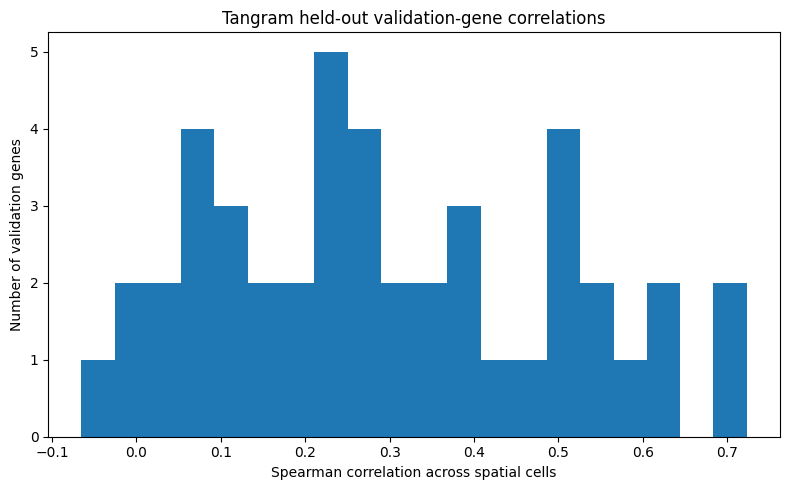

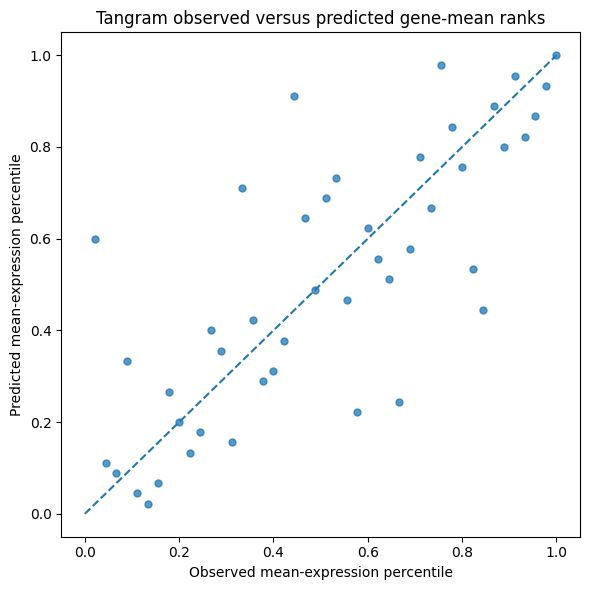

Saved: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_tangram_validation_spearman_histogram_cells_smoke.png
Saved: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_tangram_observed_vs_predicted_mean_ranks_cells_smoke.png


In [33]:
SPEARMAN_FIGURE_PATH = FIGURE_DIR / f"16_tangram_validation_spearman_histogram{RUN_SUFFIX}.png"
MEAN_RANK_FIGURE_PATH = FIGURE_DIR / f"16_tangram_observed_vs_predicted_mean_ranks{RUN_SUFFIX}.png"

plt.figure(figsize=(8, 5))
plt.hist(gene_metrics["spearman_across_cells"].dropna(), bins=20)
plt.xlabel("Spearman correlation across spatial cells")
plt.ylabel("Number of validation genes")
plt.title("Tangram held-out validation-gene correlations")
plt.tight_layout()
plt.savefig(SPEARMAN_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

mean_table = gene_metrics.copy()
mean_table["observed_mean_rank"] = mean_table["observed_mean"].rank(pct=True)
mean_table["predicted_mean_rank"] = mean_table["predicted_mean"].rank(pct=True)

plt.figure(figsize=(6, 6))
plt.scatter(mean_table["observed_mean_rank"], mean_table["predicted_mean_rank"], s=25, alpha=0.75)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Observed mean-expression percentile")
plt.ylabel("Predicted mean-expression percentile")
plt.title("Tangram observed versus predicted gene-mean ranks")
plt.tight_layout()
plt.savefig(MEAN_RANK_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", SPEARMAN_FIGURE_PATH)
print("Saved:", MEAN_RANK_FIGURE_PATH)


Spatial example genes: ['RNASE1', 'ENC1', 'HLA-B', 'CSMD1']


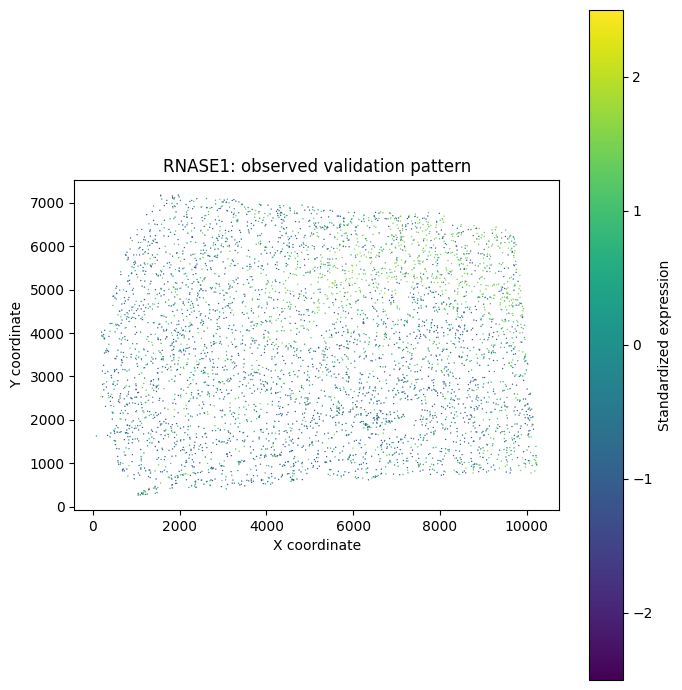

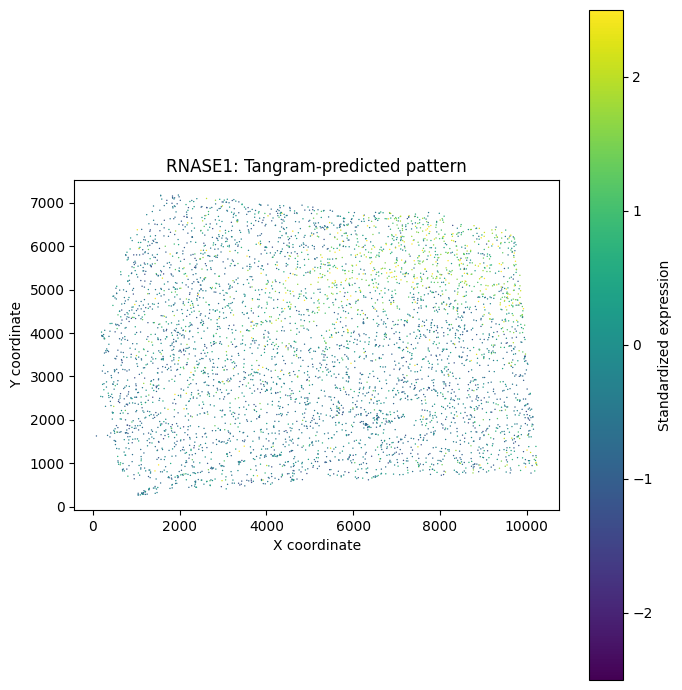

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_RNASE1_observed_cells_smoke.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_RNASE1_tangram_predicted_cells_smoke.png


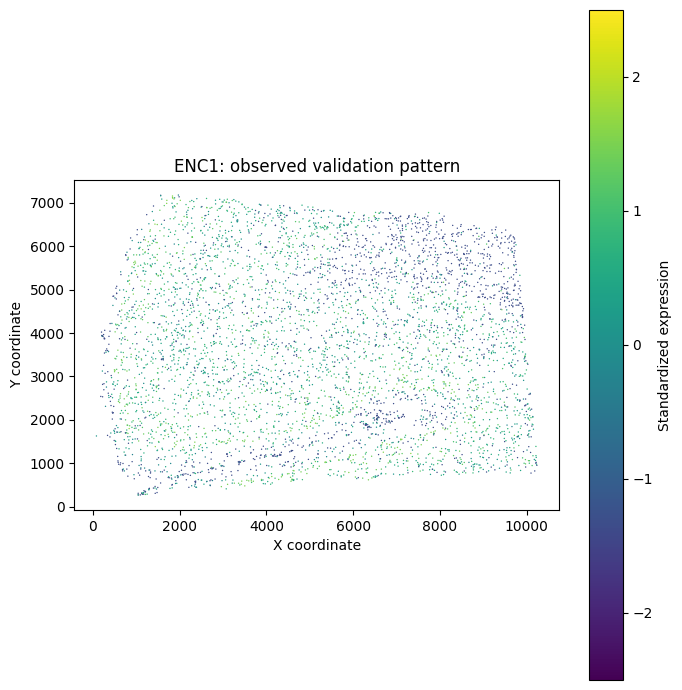

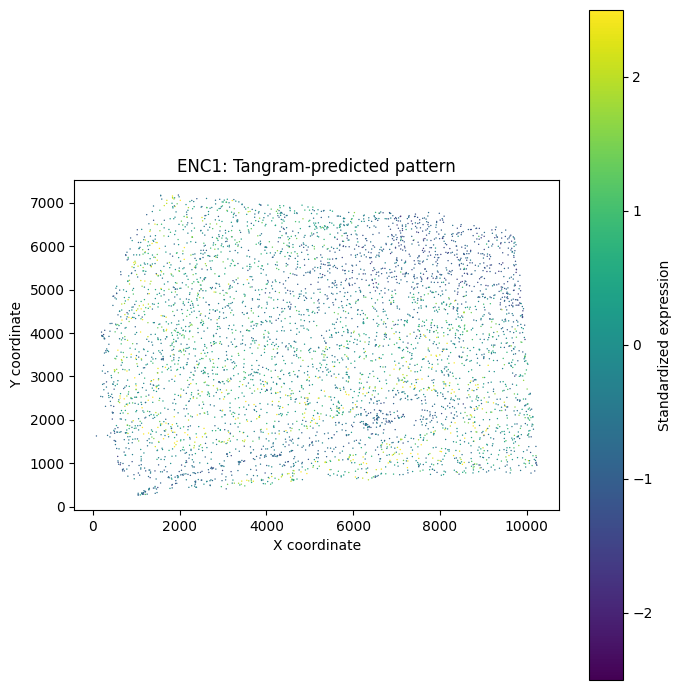

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_ENC1_observed_cells_smoke.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_ENC1_tangram_predicted_cells_smoke.png


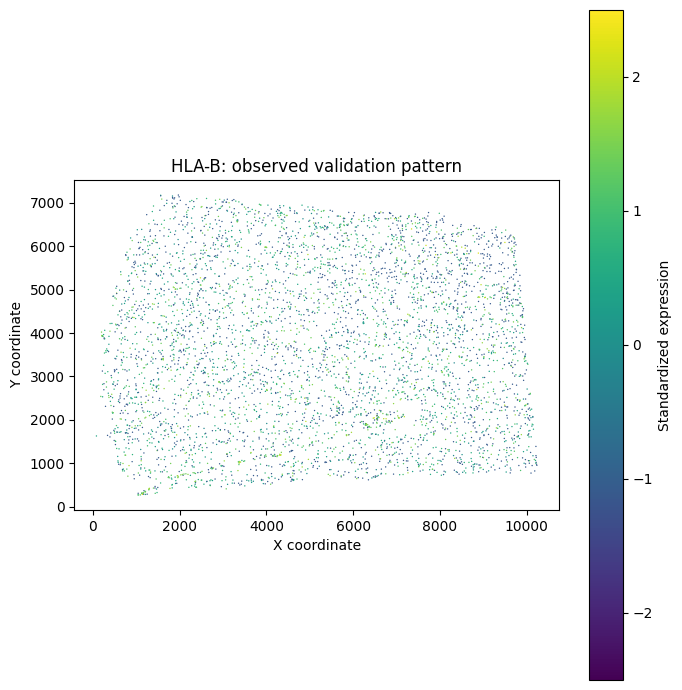

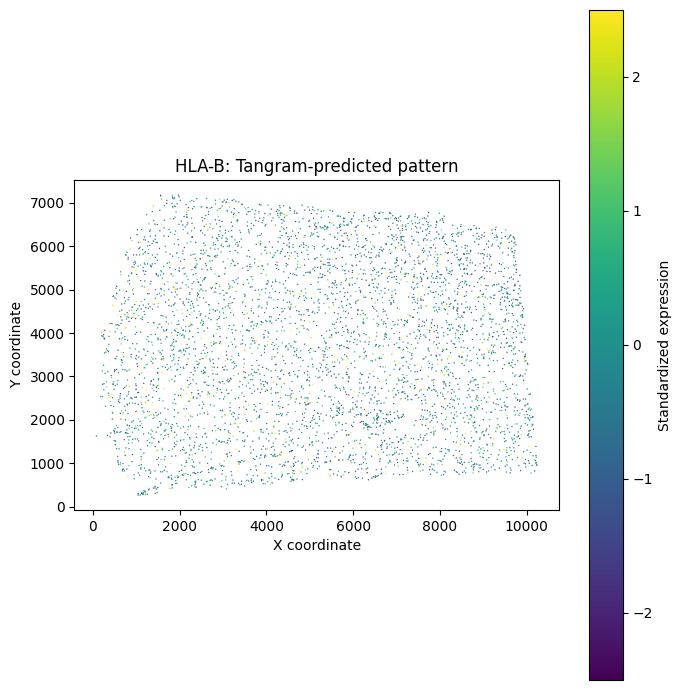

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_HLA-B_observed_cells_smoke.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_HLA-B_tangram_predicted_cells_smoke.png


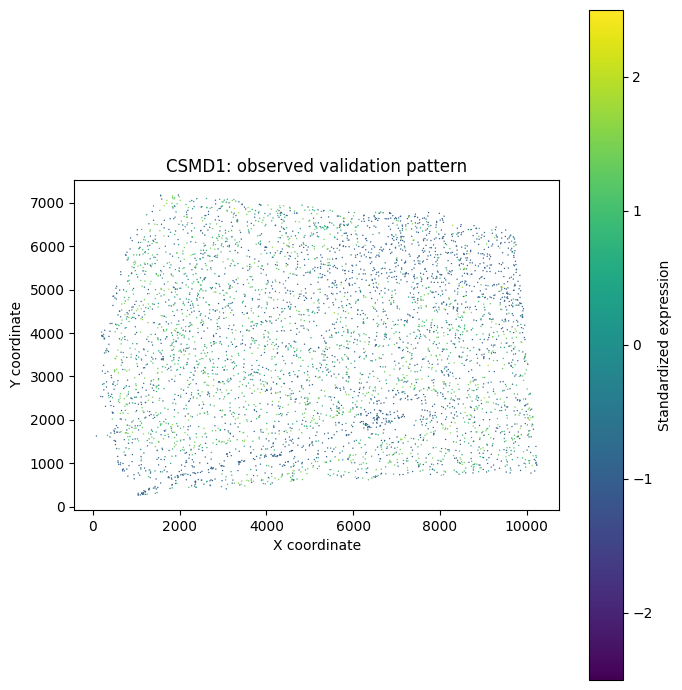

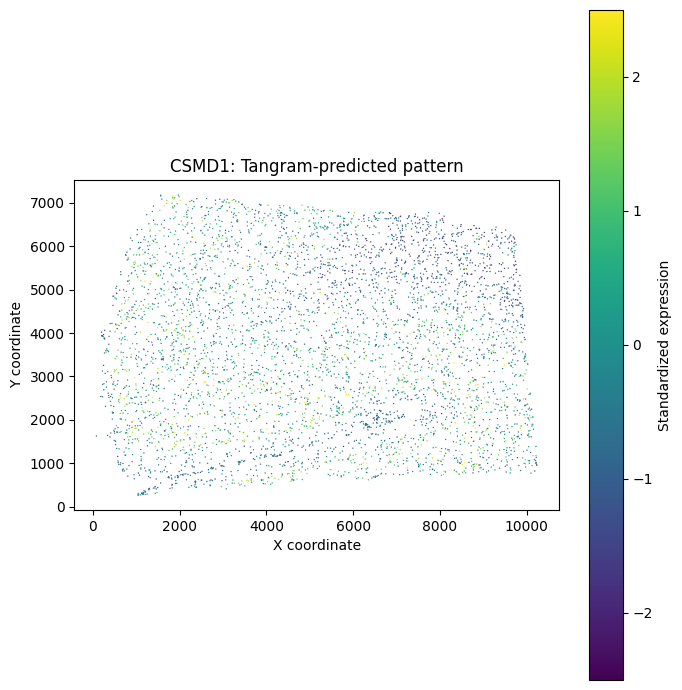

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_CSMD1_observed_cells_smoke.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/figures/16_CSMD1_tangram_predicted_cells_smoke.png


In [34]:
spatial_examples = (
    gene_metrics.sort_values("observed_variance", ascending=False)
    .head(N_SPATIAL_GENES_TO_PLOT)["gene"]
    .astype(str)
    .tolist()
)

coords = np.asarray(validation_prediction_adata.obsm["spatial"])
x = coords[:, 0]
y = coords[:, 1]
print("Spatial example genes:", spatial_examples)

for gene in spatial_examples:
    j = ordered_genes.index(gene)
    obs_vals = np.clip(zscore(observed_matrix[:, j]), -2.5, 2.5)
    pred_vals = np.clip(zscore(predicted_matrix[:, j]), -2.5, 2.5)

    obs_path = FIGURE_DIR / f"16_{gene}_observed{RUN_SUFFIX}.png"
    pred_path = FIGURE_DIR / f"16_{gene}_tangram_predicted{RUN_SUFFIX}.png"

    plt.figure(figsize=(7, 7))
    sca = plt.scatter(x, y, c=obs_vals, s=1, linewidths=0, rasterized=True, vmin=-2.5, vmax=2.5)
    plt.gca().set_aspect("equal")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"{gene}: observed validation pattern")
    plt.colorbar(sca, label="Standardized expression")
    plt.tight_layout()
    plt.savefig(obs_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(7, 7))
    sca = plt.scatter(x, y, c=pred_vals, s=1, linewidths=0, rasterized=True, vmin=-2.5, vmax=2.5)
    plt.gca().set_aspect("equal")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"{gene}: Tangram-predicted pattern")
    plt.colorbar(sca, label="Standardized expression")
    plt.tight_layout()
    plt.savefig(pred_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(obs_path)
    print(pred_path)


## 14. Output inventory

In [35]:
created_outputs = [
    MAP_PATH,
    PREDICTION_PATH,
    TRAIN_GENE_SCORE_PATH,
    TRAINING_HISTORY_PATH,
    GENE_METRICS_PATH,
    SUMMARY_PATH,
    CELLTYPE_METRICS_PATH,
    LAYER_METRICS_PATH,
    SPEARMAN_FIGURE_PATH,
    MEAN_RANK_FIGURE_PATH,
]

print("=" * 100)
print("Tangram Br8667 validation workflow completed")
print("=" * 100)
for p in created_outputs:
    print(f"{'EXISTS' if p.exists() else 'MISSING'}: {p}")

print("\nBlind test was not loaded or evaluated in this notebook.")
if RUN_MODE == "smoke":
    print("This was a smoke run. Set RUN_MODE='full' for the scientific validation result.")
if TANGRAM_MODE == "clusters":
    print("Cluster mode: fast and robust, but predictions are cluster-average driven.")
else:
    print("Cell mode: closer to original Tangram, but the mapping matrix is much larger.")


Tangram Br8667 validation workflow completed
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/16_tangram_map_cells_smoke.h5ad
EXISTS: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/tangram_validation_predictions_45genes_cells_smoke.h5ad
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/16_tangram_training_gene_scores_cells_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/16_tangram_training_history_cells_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/16_tangram_validation_gene_metrics_cells_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/16_tangram_validation_summary_cells_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/tangram/16_tangram_validation_ce

## Next step

After validation, compare Tangram against SpaGE, gimVI, and VISTA using the same 45 validation genes. Choose Tangram mode and epochs using validation only. Then freeze the configuration, create the final 255-gene input, rerun Tangram once, and evaluate once on the 45 blind-test genes.
